In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [14]:
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [15]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [16]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')

Сгруппируйте данные по дате, посчитайте количество продаж

In [17]:
grouped_df = (
    df.groupby('Дата', as_index=False)['Количество']
      .sum()
      .rename(columns={'Количество': 'Количество продаж'})
)

Вывести несколько первых строк сгруппированных данных

In [18]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

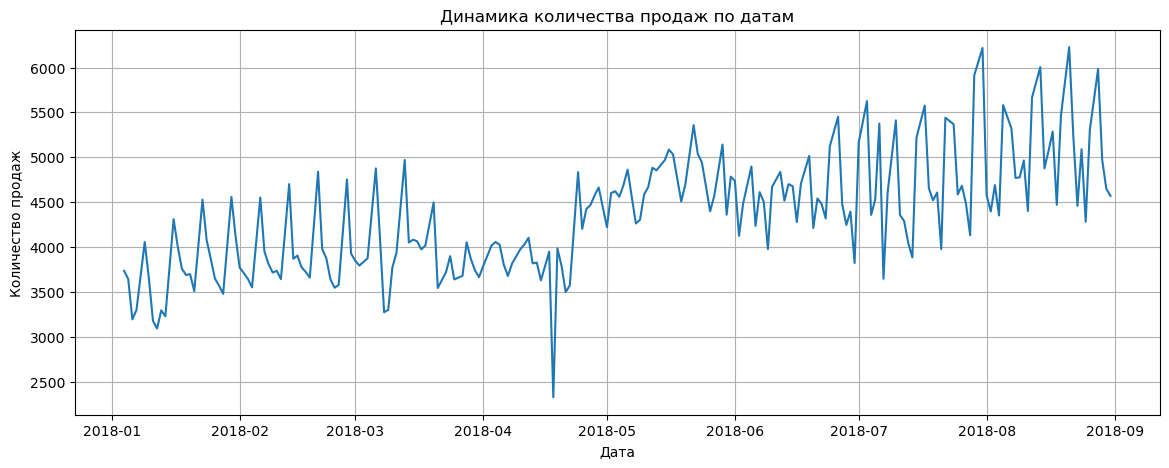

In [19]:
plt.figure(figsize=(14,5))
sns.lineplot(data=grouped_df, x='Дата', y='Количество продаж')
plt.title('Динамика количества продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [16]:
# На графике видно, как меняется количество продаж по дням. 
# Есть периоды роста и падения, что может быть связано с днями недели, сезонностью или активностью клиентов. 
# Также можно заметить отдельные пики — дни, когда продажи были значительно выше среднего уровня.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [20]:
outlier_row = grouped_df.loc[grouped_df['Количество продаж'].idxmax()]
outlier_row

Дата                 2018-08-21 00:00:00
Количество продаж                   6226
Name: 195, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [21]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df['Месяц'] = df['Дата'].dt.month
df['День_недели'] = df['Дата'].dt.weekday  # 0=Пн, 2=Ср

mask = (
    (df['Склад'] == 3) &
    (df['Месяц'].isin([6, 7, 8])) &
    (df['День_недели'] == 2)  # среда
)

filtered = df[mask]

top_product = (
    filtered.groupby('Номенклатура', as_index=False)['Количество']
            .sum()
            .sort_values('Количество', ascending=False)
            .head(1)
)

top_product

,Номенклатура,Количество
1,product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [22]:
!pip install xlrd

weather = pd.read_excel('weather.xls', skiprows=6)

In [23]:
weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [24]:
weather = weather[['Местное время в Астане', 'T']]

In [25]:
weather['Местное время в Астане'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True, errors='coerce')

In [26]:
weather['Дата'] = weather['Местное время в Астане'].dt.date

weather_daily = (
    weather.groupby('Дата', as_index=False)['T']
           .mean()
           .rename(columns={'T': 'Температура'})
)

weather_daily

,Дата,Температура
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625
5,2018-01-06,-13.3000
6,2018-01-07,-12.7500
7,2018-01-08,-15.4125
8,2018-01-09,-6.2500
9,2018-01-10,-1.4875


In [27]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])
weather_daily['Дата'] = pd.to_datetime(weather_daily['Дата'])

In [28]:
merged = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')
merged.head()

,Дата,Количество продаж,Температура
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


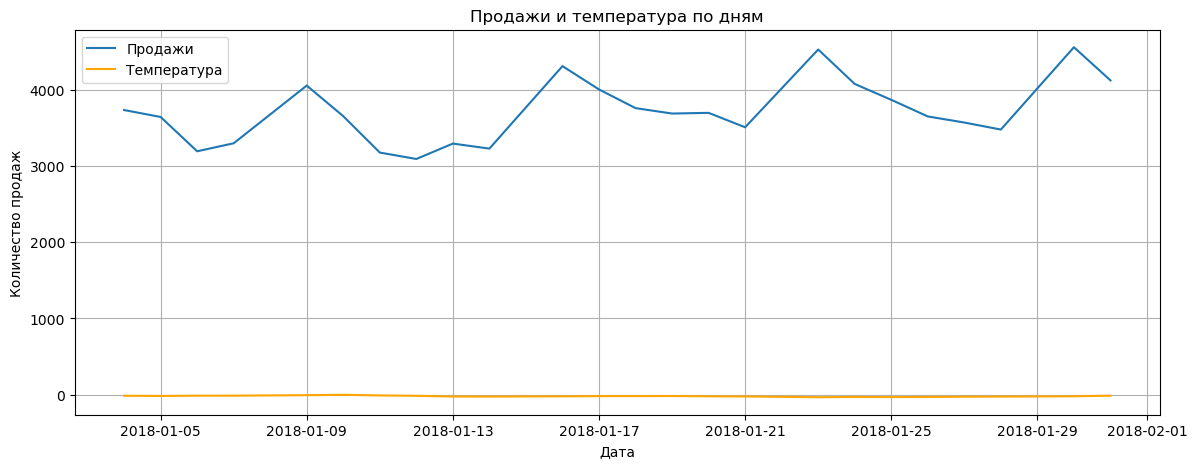

In [29]:
plt.figure(figsize=(14,5))

sns.lineplot(data=merged, x='Дата', y='Количество продаж', label='Продажи')
sns.lineplot(data=merged, x='Дата', y='Температура', label='Температура', color='orange')

plt.title('Продажи и температура по дням')
plt.xlabel('Дата')
plt.grid(True)
plt.legend()
plt.show()

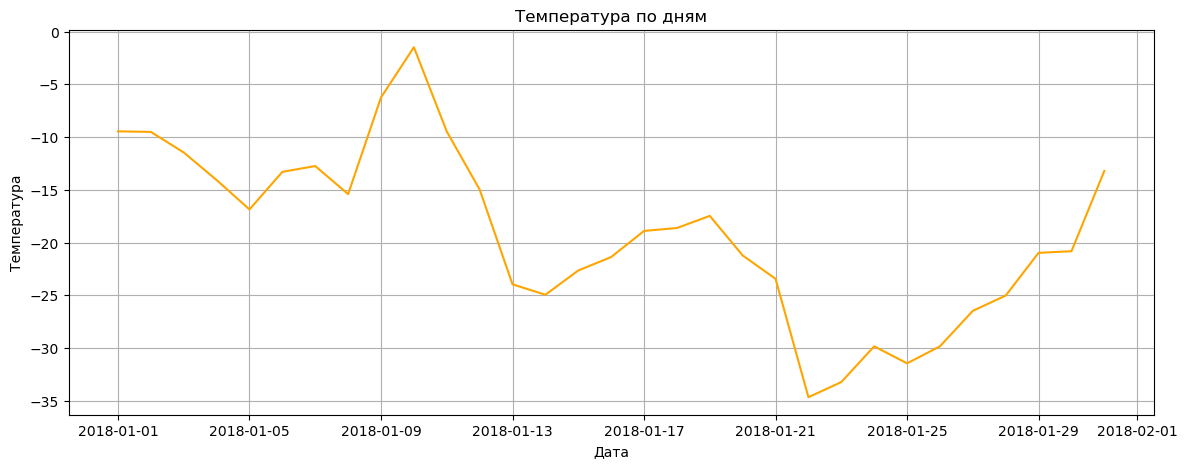

In [30]:
plt.figure(figsize=(14,5))

sns.lineplot(data=weather_daily, x='Дата', y='Температура', color='orange')

plt.title('Температура по дням')
plt.xlabel('Дата')
plt.grid(True)
plt.show()